# Netflix Movie Data Analysis

This project explores a movie dataset using Python, Pandas, Matplotlib, and Seaborn.  
The analysis focuses on genres, vote categories, popularity, and release-year trends.

## Project questions

1. Which genres appear most frequently?
2. Which vote category has the highest number of movies?
3. Which movies are the most and least popular?
4. Which years had the highest number of movie releases?
5. Is there any relationship between popularity, vote count, and vote average?


## Phase-1: Importing Modules and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mymoviedb.csv", lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


## Phase 2 — Initial data inspection

In [3]:
print("Shape:",df.shape)
df.info()

Shape: (9827, 9)
<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [4]:
df['Genre'].head() # in order to find the types of genre being used in the dataset

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
print(df.describe())

        Popularity    Vote_Count  Vote_Average
count  9827.000000   9827.000000   9827.000000
mean     40.326088   1392.805536      6.439534
std     108.873998   2611.206907      1.129759
min      13.354000      0.000000      0.000000
25%      16.128500    146.000000      5.900000
50%      21.199000    444.000000      6.500000
75%      35.191500   1376.000000      7.100000
max    5083.954000  31077.000000     10.000000


In [7]:
# Release-Date datatype/format needs to be changed
# white spaces between the Genre types may or may not needed to be removed
# dropping down the columns that needs not analysis(like-overview, language and poster url)
# All of these things needs to be done in the data preprocessing.
# Insights gained till now-


### Exploratory summary
- we have a dataframe consisting of 9827 entries and 9 columns.
- our dataset looks a bit tidy with no NaNs or duplicated values.
- Release_Date column need to be casted into date time and to extract only the year value.
- Overview, Original_Language and Poster-Url wouldn't be so useful during analysis, so we'll drop them.
- There is noticable outliers in the Popularity column.
- Vote_Average better be categorised for proper analysis.
- Genre column has comma separated values and white spaces that needs to be handled and casted into category.

### Phase-3: Cleaning Data and Preprocessing

In [8]:
# changing the date time format of the Release_Date column

df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

datetime64[us]


dtype('int32')

In [9]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


#### Dropping down the irrelevant columns

In [10]:
# Overview, Original_Language, Poster_Url column to be dropped

cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis = 1, inplace = True)
df.columns


Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [11]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


#### **Categorizing** `Vote_Average` column  
We would cut the `Vote_Average` values and make 4 categories `popular`,`average`, `below_avg` , `not_popular` to describe it more using categorize_col() function provided

In [12]:
# creating a user defined function to label the popularity of the movie

def categorize_col(df, col, labels):
    
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df

In [13]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [15]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [16]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


#### Now let's explode the Genre column into a list and will have each movie representing only each type of Genre

In [18]:
print(df['Genre'].head())

print(df['Genre'].dtype)

print(df['Genre'].iloc[0])

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str
str
Action, Adventure, Science Fiction


In [19]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre', ignore_index=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [20]:
# casting column into category

df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  str     
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), str(1)
memory usage: 749.1 KB


In [22]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

## Phase 4 — Exploratory Data Analysis

In [23]:
sns.set_style('whitegrid')

### What is the most frequent genre of movies released on Netflix?

In [24]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

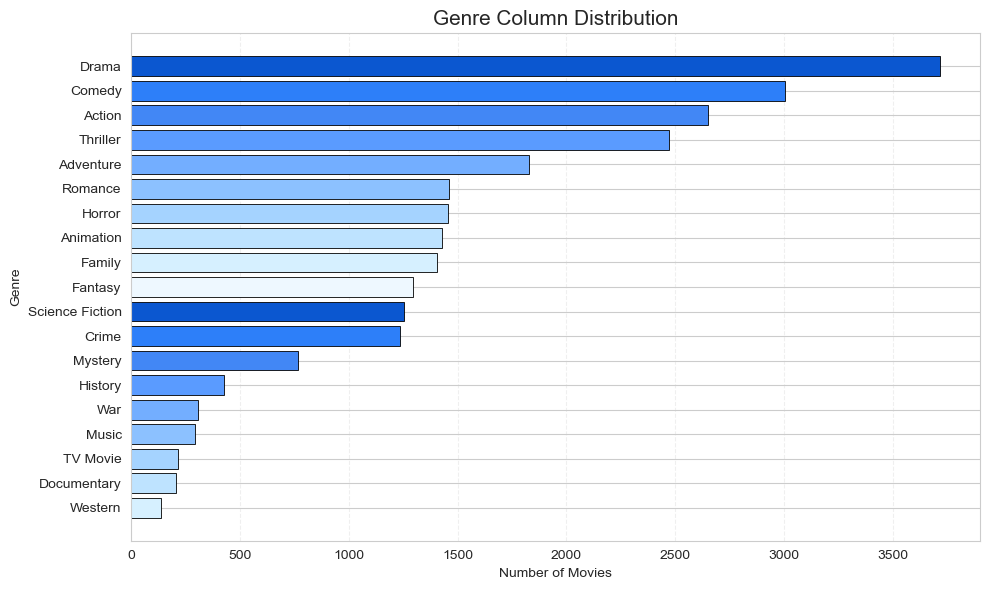

In [25]:
genre_count = df['Genre'].value_counts()

colors = [
    '#0B57D0', '#2D7FF9', '#4287F5', '#5A9BFF',
    '#73AEFF', '#8CC1FF', '#A5D3FF', '#BEE3FF',
    '#D6F0FF', '#EEF8FF'
]

plt.figure(figsize=(10, 6))

plt.barh(
    genre_count.index,
    genre_count.values,
    color=colors,
    edgecolor='black',
    linewidth=0.6
)

plt.title('Genre Column Distribution', fontsize=15)
plt.xlabel('Number of Movies')
plt.ylabel('Genre')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "genre_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Which has highest votes in vote avg column

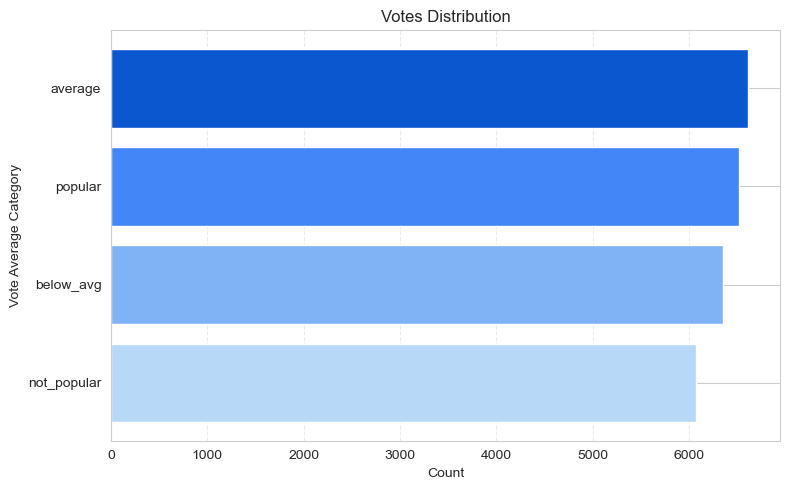

In [26]:
vote_counts = df['Vote_Average'].value_counts().sort_values()

colors = ['#B8D8F8', '#7FB3F5', '#4287F5', '#0B57D0']

plt.figure(figsize=(8,5))

plt.barh(vote_counts.index,
         vote_counts.values,
         color=colors)
plt.barh(vote_counts.index, vote_counts.values, color= colors)

plt.title('Votes Distribution')
plt.xlabel('Count')
plt.ylabel('Vote Average Category')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "vote_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

### Which movie got the highest popularity? What's its genre?

In [27]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [28]:
df[df['Popularity'] == df['Popularity'].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


### Which movie got the lowest popularity? What's its Genre?

In [29]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


### Which year has the most filmed movies?

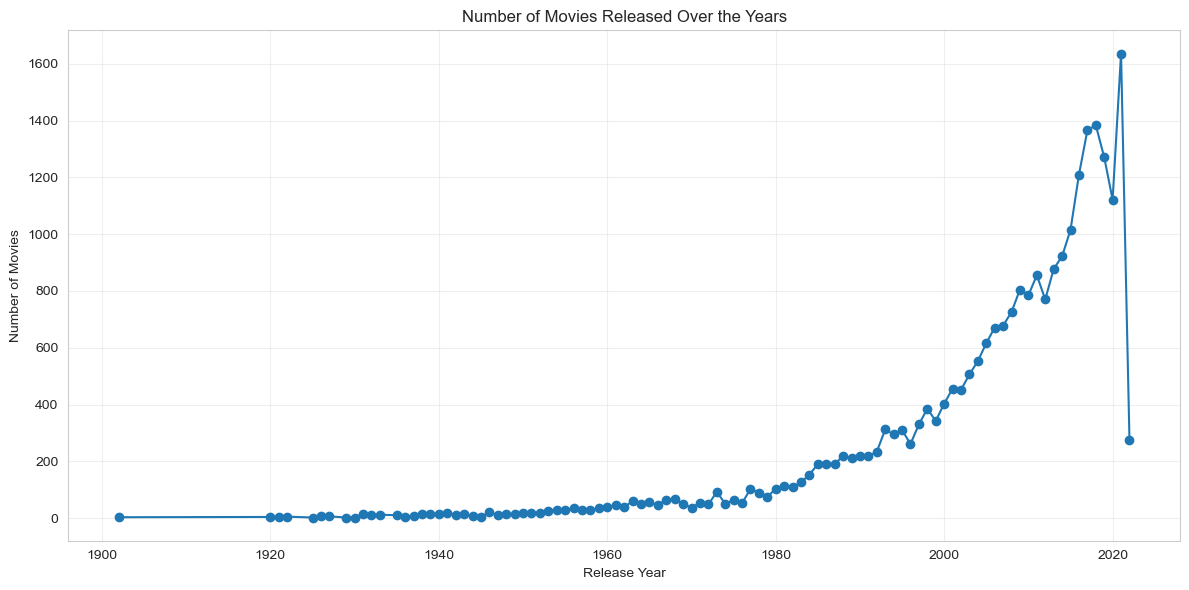

In [30]:
plt.figure(figsize=(12,6))

year_counts = df['Release_Date'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Number of Movies Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "release_year_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Summary

### Conclusion

- **Drama** appears most frequently in the dataset, followed by Comedy, Action, and Thriller.
- The dataset is almost evenly distributed across the four vote categories created using quartiles.
- **Spider-Man: No Way Home** has the highest popularity score in the dataset.
- **2021** has the highest number of movie releases in the dataset.
- Popularity and vote count show a weak positive relationship, but popularity does not strongly depend on vote average alone.
- Genre-wise analysis becomes more meaningful after splitting and exploding the `Genre` column.


In [31]:
import numpy
import pandas
import matplotlib
import seaborn

print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)

NumPy: 2.4.6
Pandas: 3.0.3
Matplotlib: 3.10.9
Seaborn: 0.13.2
